# Dos algoritmos, dos juegos de ingenio
1. **Árbol de decisión → Akinator casero** : un árbol que adivina en qué animal estás pensando. Un árbol de decisión *es* el juego de las 20 preguntas.
2. **Bayes ingenuo → Detective Bayes** : ¿quién se comió el último pedazo de pizza del laboratorio? El modelo actualiza sus sospechas pista por pista.



## Parte 1: Akinator casero con un árbol de decisión

**Idea:** Akinator hace preguntas de sí/no y en pocos pasos adivina el personaje. Un árbol de decisión hace exactamente eso: cada **nodo** es una pregunta, cada **rama** es una respuesta y cada **hoja** es la adivinanza final.

La clave está en *qué pregunta hacer primero*. El algoritmo elige la que más reduce la incertidumbre (mayor **ganancia de información**, medida con la **entropía**).

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
import warnings
warnings.filterwarnings("ignore", category=UserWarning)   # sklearn avisa porque cada animal es su propia clase

preguntas = {
    "vive_en_agua":        "¿Vive en el agua?",
    "vuela":               "¿Puede volar?",
    "tiene_pelo":          "¿Tiene pelo?",
    "tiene_plumas":        "¿Tiene plumas?",
    "pone_huevos":         "¿Nace de un huevo?",
    "es_carnivoro":        "¿Come carne?",
    "es_domestico":        "¿Puede vivir en una casa o granja con personas?",
    "es_grande":           "¿Es más grande que una persona?",
    "tiene_cuatro_patas":  "¿Camina sobre cuatro patas?",
    "es_nocturno":         "¿Es activo sobre todo de noche?",
    "tiene_rayas_manchas": "¿Tiene rayas o manchas muy visibles?",
    "vive_en_selva":       "¿Vive en selva o sabana?",
}
columnas = list(preguntas.keys())

#                 agua vuela pelo plum huev carn dom  grande 4pat noct rayas selva
animales = {
    "perro":       [0,0,1,0,0,1,1,0,1,0,0,0],
    "gato":        [0,0,1,0,0,1,1,0,1,1,0,0],
    "vaca":        [0,0,1,0,0,0,1,1,1,0,1,0],
    "caballo":     [0,0,1,0,0,0,1,1,1,0,0,0],
    "conejo":      [0,0,1,0,0,0,1,0,1,0,0,0],
    "gallina":     [0,0,0,1,1,0,1,0,0,0,0,0],
    "pato":        [1,1,0,1,1,0,1,0,0,0,0,0],
    "loro":        [0,1,0,1,1,0,1,0,0,0,0,1],
    "águila":      [0,1,0,1,1,1,0,0,0,0,0,0],
    "búho":        [0,1,0,1,1,1,0,0,0,1,0,0],
    "pingüino":    [1,0,0,1,1,1,0,0,0,0,0,0],
    "delfín":      [1,0,0,0,0,1,0,1,0,0,0,0],
    "tiburón":     [1,0,0,0,1,1,0,1,0,0,0,0],
    "pulpo":       [1,0,0,0,1,1,0,0,0,1,0,0],
    "rana":        [1,0,0,0,1,1,0,0,1,1,0,1],
    "tortuga":     [1,0,0,0,1,0,0,0,1,0,0,0],
    "cocodrilo":   [1,0,0,0,1,1,0,1,1,0,0,1],
    "serpiente":   [0,0,0,0,1,1,0,0,0,0,1,1],
    "murciélago":  [0,1,1,0,0,0,0,0,0,1,0,1],
    "mariposa":    [0,1,0,0,1,0,0,0,0,0,1,1],
    "león":        [0,0,1,0,0,1,0,1,1,0,0,1],
    "tigre":       [0,0,1,0,0,1,0,1,1,1,1,1],
    "cebra":       [0,0,1,0,0,0,0,1,1,0,1,1],
    "elefante":    [0,0,0,0,0,0,0,1,1,0,0,1],
    "mono":        [0,0,1,0,0,0,0,0,1,0,0,1],
    "oso":         [0,0,1,0,0,1,0,1,1,0,0,0],
}

df = pd.DataFrame(animales, index=columnas).T
assert df.duplicated().sum() == 0, "Hay dos animales idénticos: el árbol no podría separarlos"
print(f"{len(df)} animales, {len(columnas)} preguntas posibles")
df.head()

26 animales, 12 preguntas posibles


,vive_en_agua,vuela,tiene_pelo,tiene_plumas,pone_huevos,es_carnivoro,es_domestico,es_grande,tiene_cuatro_patas,es_nocturno,tiene_rayas_manchas,vive_en_selva
perro,0,0,1,0,0,1,1,0,1,0,0,0
gato,0,0,1,0,0,1,1,0,1,1,0,0
vaca,0,0,1,0,0,0,1,1,1,0,1,0
caballo,0,0,1,0,0,0,1,1,1,0,0,0
conejo,0,0,1,0,0,0,1,0,1,0,0,0


Define la "memoria" de Akinator: una tabla con 26 animales y 12 características de sí/no (1 = sí, 0 = no). El `assert` comprueba que no haya dos animales con exactamente las mismas respuestas, porque entonces ninguna pregunta podría distinguirlos. (Los datos están simplificados a propósito.)

In [ ]:
# ¿Cuánta incertidumbre hay al inicio? Con 26 animales posibles igual de probables:
def entropia(etiquetas):
    _, cuentas = np.unique(etiquetas, return_counts=True)
    p = cuentas / cuentas.sum()
    return -(p * np.log2(p)).sum()

H_inicial = entropia(df.index)
print(f"Entropía inicial: {H_inicial:.2f} bits  (= log2(26))")

# Ganancia de información de cada pregunta si la hiciéramos primero
ganancias = {}
for col in columnas:
    si, no = df[df[col] == 1], df[df[col] == 0]
    H_despues = (len(si)/len(df))*entropia(si.index) + (len(no)/len(df))*entropia(no.index)
    ganancias[col] = H_inicial - H_despues

ranking = pd.Series(ganancias).sort_values(ascending=False)
print()
print(ranking.round(3).to_string())

Entropía inicial: 4.70 bits  (= log2(26))

pone_huevos            1.000
es_carnivoro           0.996
tiene_cuatro_patas     0.996
tiene_pelo             0.983
vive_en_selva          0.983
es_grande              0.961
vive_en_agua           0.890
es_domestico           0.890
tiene_plumas           0.779
vuela                  0.779
es_nocturno            0.779
tiene_rayas_manchas    0.706


Calcula a mano lo que el algoritmo hace internamente.
- La **entropía** mide cuánta incertidumbre hay (en *bits*). Con 26 animales posibles es log₂(26) ≈ 4.7 bits: como mínimo se necesitan unas 5 preguntas de sí/no para adivinar.
- Para cada pregunta calcula cuánta entropía quedaría después de hacerla. La diferencia es la **ganancia de información**.
- La pregunta con mayor ganancia es la que el árbol hará primero (la que parte los animales en grupos más parejos).

Exactitud sobre los animales conocidos: 1.0
Profundidad del árbol: 5
Primera pregunta que eligió: ¿Nace de un huevo?


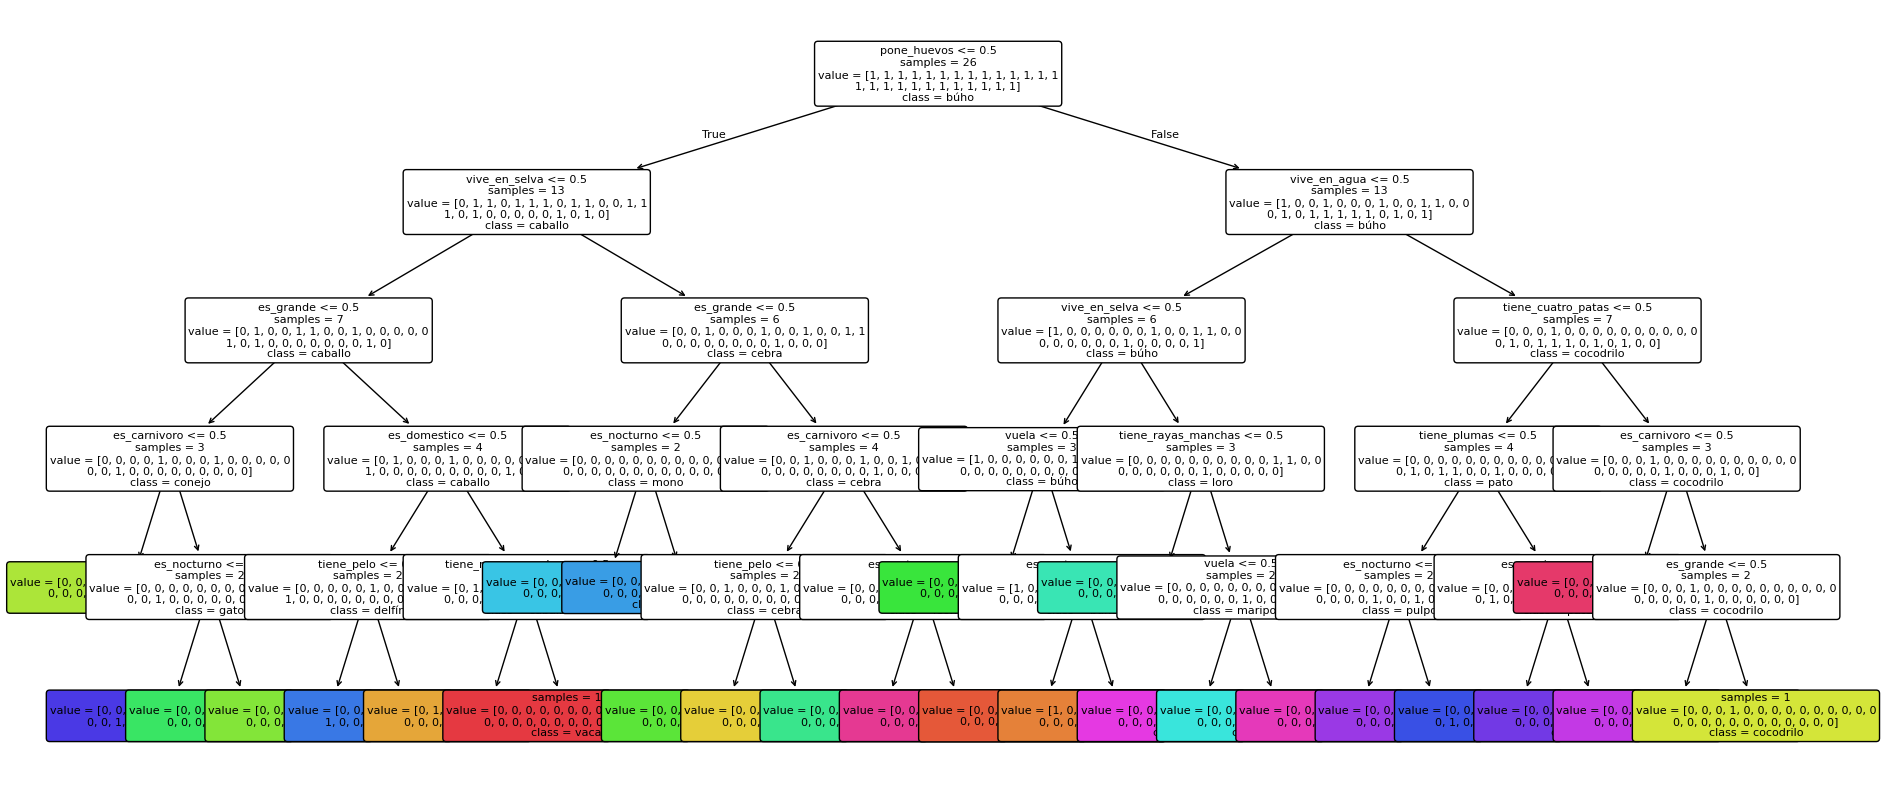

In [ ]:
X = df.values
y = df.index.values

arbol = DecisionTreeClassifier(criterion="entropy", random_state=0)
arbol.fit(X, y)

print("Exactitud sobre los animales conocidos:", arbol.score(X, y))
print("Profundidad del árbol:", arbol.get_depth())
print("Primera pregunta que eligió:", preguntas[columnas[arbol.tree_.feature[0]]])

plt.figure(figsize=(22, 10))
plot_tree(arbol, feature_names=columnas, class_names=list(arbol.classes_),
          filled=True, rounded=True, fontsize=8, impurity=False)
plt.show()

Entrena el árbol con `criterion="entropy"` (usa la ganancia de información que calculamos arriba) y lo dibuja. Lee el dibujo así: en cada recuadro, si la respuesta es **sí** vas a la derecha y si es **no** a la izquierda, hasta llegar a una hoja, que es el animal. No hay `max_depth` a propósito: aquí *queremos* que el árbol separe a todos los animales.

In [ ]:
def jugar(arbol, columnas, preguntas, respuesta_fn):
    """Recorre el árbol haciendo preguntas. respuesta_fn(col, pregunta) devuelve 1 (sí) o 0 (no)."""
    t = arbol.tree_
    nodo, n = 0, 0
    while t.children_left[nodo] != -1:                 # mientras no sea una hoja
        col = columnas[t.feature[nodo]]
        n += 1
        r = respuesta_fn(col, preguntas[col])
        nodo = t.children_right[nodo] if r == 1 else t.children_left[nodo]
    adivinanza = arbol.classes_[np.argmax(t.value[nodo])]
    return adivinanza, n

def respuesta_humana(col, pregunta):
    while True:
        r = input(f"{pregunta} (s/n): ").strip().lower()
        if r in ("s", "n"):
            return 1 if r == "s" else 0

# --- Modo automático: el programa conoce el animal secreto y responde por nosotros ---
def partida_automatica(secreto):
    print(f" Animal secreto: {secreto}")
    def responder(col, pregunta):
        r = int(df.loc[secreto, col])
        print(f"   {pregunta} -> {'Sí' if r else 'No'}")
        return r
    adivinanza, n = jugar(arbol, columnas, preguntas, responder)
    print(f"¡Creo que es: {adivinanza.upper()}! (en {n} preguntas)\n")

partida_automatica("tigre")
partida_automatica("pingüino")

🤫 Animal secreto: tigre
   ¿Nace de un huevo? -> No
   ¿Vive en selva o sabana? -> Sí
   ¿Es más grande que una persona? -> Sí
   ¿Come carne? -> Sí
   ¿Es activo sobre todo de noche? -> Sí
🧞 ¡Creo que es: TIGRE! (en 5 preguntas)

🤫 Animal secreto: pingüino
   ¿Nace de un huevo? -> Sí
   ¿Vive en el agua? -> Sí
   ¿Camina sobre cuatro patas? -> No
   ¿Tiene plumas? -> Sí
   ¿Come carne? -> Sí
🧞 ¡Creo que es: PINGÜINO! (en 5 preguntas)



 `jugar` es el Akinator. Parte de la raíz del árbol, hace la pregunta de ese nodo, y según la respuesta baja por la rama derecha (sí) o izquierda (no). Cuando llega a una hoja, esa es su adivinanza.

`partida_automatica` simula una partida: el animal secreto responde por nosotros (leyendo la tabla) y se imprime cada pregunta con su respuesta, para que veas el recorrido por el árbol.

In [15]:
adivinanza, n = jugar(arbol, columnas, preguntas, respuesta_humana)
print(f" ¡Creo que es: {adivinanza.upper()}! (en {n} preguntas)")

KeyError: 'calzado'

In [ ]:
# ¿Cuántas preguntas necesita para cada animal?
profundidad_por_animal = arbol.decision_path(X).sum(axis=1).A1 - 1
minimo_teorico = np.log2(len(df))

pd.Series(profundidad_por_animal, index=y).sort_values().plot(
    kind="barh", figsize=(7, 7), color="mediumpurple")
plt.axvline(minimo_teorico, color="red", linestyle="--", label=f"Mínimo teórico ≈ {minimo_teorico:.1f}")
plt.xlabel("Preguntas necesarias")
plt.title("¿Qué tan eficiente es nuestro Akinator?")
plt.legend(); plt.show()

print(f"Promedio: {profundidad_por_animal.mean():.2f} preguntas | Máximo: {profundidad_por_animal.max()}")

Cuenta cuántas preguntas necesita el árbol para cada animal y lo compara con el mínimo teórico (la línea roja: ~4.7 preguntas, que sale de la entropía). Un árbol perfecto separaría todo en ~5 preguntas; *este* se acerca bastante, porque cada pregunta elegida por ganancia de información parte los animales en grupos parecidos.

## Parte 2: Detective Bayes — el caso de la pizza desaparecida

**Idea:** alguien del laboratorio se comió el último pedazo de pizza. Tenemos 5 sospechosos y, de **casos anteriores**, sabemos sus costumbres (a qué hora actúan, dónde dejan migas, etc.). Cuando aparece una pista nueva, usamos el **teorema de Bayes** para actualizar nuestra sospecha:

$$P(\text{culpable} \mid \text{pistas}) \propto P(\text{culpable}) \cdot \prod_i P(\text{pista}_i \mid \text{culpable})$$

Es **ingenuo** porque trata cada pista como independiente de las demás dado el culpable. Cada pista mueve las probabilidades.

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.naive_bayes import CategoricalNB

rng = np.random.default_rng(7)

# Costumbres de cada sospechoso: P(pista | culpable), en el orden de las categorías de cada pista
categorias = {
    "hora":    ["mañana", "tarde", "noche"],
    "migas":   ["cocina", "sala_de_juntas", "laboratorio"],
    "salsa":   ["camisa", "teclado", "ninguna"],
    "testigo": ["gorra", "audífonos", "mochila"],
    "calzado": ["tenis", "botas", "tacones"],
}
habitos = {
    #            hora              migas             salsa             testigo           calzado
    "Ana":    ([.1,.2,.7],     [.2,.1,.7],     [.1,.7,.2],     [.1,.8,.1],      [.7,.2,.1]),
    "Beto":   ([.6,.3,.1],     [.7,.2,.1],     [.6,.1,.3],     [.7,.2,.1],      [.3,.6,.1]),
    "Carla":  ([.2,.6,.2],     [.3,.5,.2],     [.2,.2,.6],     [.1,.2,.7],      [.1,.1,.8]),
    "Dani":   ([.3,.3,.4],     [.4,.2,.4],     [.3,.3,.4],     [.34,.33,.33],   [.5,.3,.2]),
    "Elena":  ([.1,.7,.2],     [.5,.4,.1],     [.5,.2,.3],     [.2,.1,.7],      [.2,.1,.7]),
}
# Cuántos pizzas ha robado cada uno en el pasado (esto será la probabilidad previa)
casos_previos = {"Ana": 80, "Beto": 60, "Carla": 50, "Dani": 70, "Elena": 40}

filas = []
for nombre, dists in habitos.items():
    for _ in range(casos_previos[nombre]):
        fila = {"culpable": nombre}
        for (col, cats), p in zip(categorias.items(), dists):
            fila[col] = rng.choice(cats, p=p)
        filas.append(fila)

historial_casos = pd.DataFrame(filas).sample(frac=1, random_state=1).reset_index(drop=True)
print(f"{len(historial_casos)} casos anteriores")
historial_casos.head(8)

300 casos anteriores


,culpable,hora,migas,salsa,testigo,calzado
0,Carla,mañana,sala_de_juntas,ninguna,mochila,tacones
1,Beto,tarde,cocina,camisa,audífonos,botas
2,Carla,mañana,sala_de_juntas,ninguna,mochila,tacones
3,Dani,tarde,laboratorio,camisa,audífonos,botas
4,Beto,mañana,cocina,camisa,audífonos,botas
5,Beto,tarde,cocina,teclado,gorra,botas
6,Carla,noche,sala_de_juntas,camisa,mochila,tenis
7,Ana,noche,laboratorio,teclado,audífonos,tenis


Simula el archivo de casos anteriores de la oficina. Cada sospechoso tiene sus costumbres (por ejemplo, Ana es noctámbula, deja migas en el laboratorio y usa audífonos), y se generan 300 "casos" al azar respetándolas. Ana ha robado más veces que Elena, así que ya parte con más sospecha antes de ver ninguna pista: esa es la **probabilidad previa**.

In [11]:
columnas = list(categorias.keys())
X = historial_casos[columnas]
y = historial_casos["culpable"]

codificador = OrdinalEncoder(categories=[categorias[c] for c in columnas])
X_num = codificador.fit_transform(X).astype(int)       # texto -> números (0,1,2)

X_tr, X_te, y_tr, y_te = train_test_split(X_num, y, test_size=0.2, random_state=0, stratify=y)

modelo = CategoricalNB(alpha=1.0)                       # alpha=1: suavizado de Laplace
modelo.fit(X_tr, y_tr)

print(f"Exactitud adivinando culpables en casos nuevos: {modelo.score(X_te, y_te):.1%}")
print("Probabilidad previa de cada sospechoso:")
print(pd.Series(np.exp(modelo.class_log_prior_), index=modelo.classes_).round(3).to_string())

Exactitud adivinando culpables en casos nuevos: 70.0%
Probabilidad previa de cada sospechoso:
Ana      0.267
Beto     0.200
Carla    0.167
Dani     0.233
Elena    0.133


Convierte las pistas de texto a números, separa casos de entrenamiento y de prueba, y entrena `CategoricalNB` (la versión de Bayes ingenuo para variables con categorías). El modelo aprende dos cosas:
- La **probabilidad previa** de cada culpable (qué tan frecuente es en el archivo).
- La **probabilidad de cada pista dado cada culpable** (por ejemplo, qué tan probable es ver "audífonos" si es Ana).

La exactitud sobre casos de prueba nos dice qué tan buen detective es (con 5 sospechosos, adivinar al azar daría 20%).

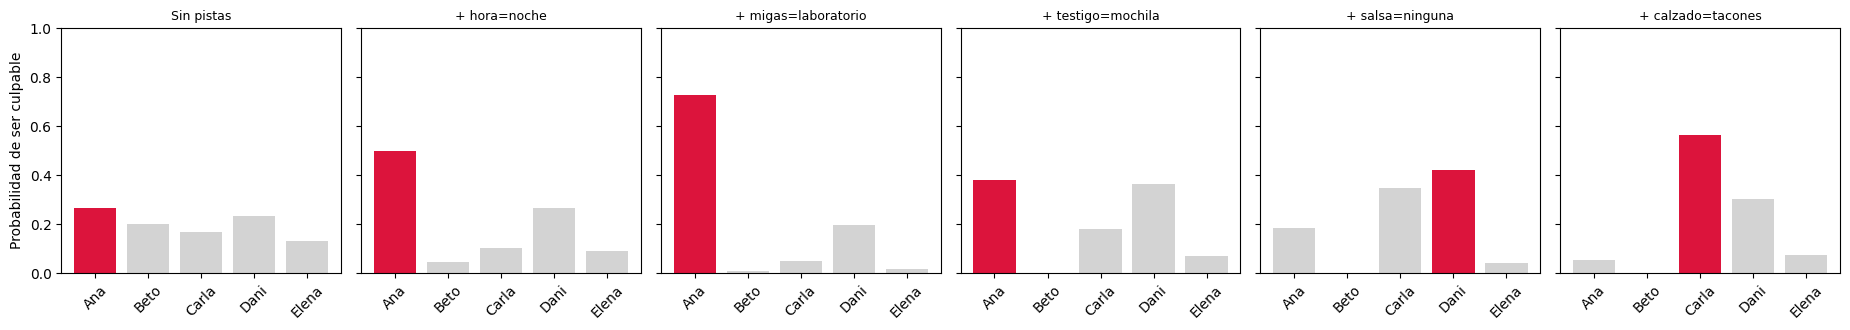

,Sin pistas,+ hora=noche,+ migas=laboratorio,+ testigo=mochila,+ salsa=ninguna,+ calzado=tacones
Ana,0.27,0.50,0.73,0.38,0.18,0.05
Beto,0.20,0.05,0.01,0.00,0.00,0.00
Carla,0.17,0.10,0.05,0.18,0.35,0.57
Dani,0.23,0.27,0.20,0.37,0.42,0.30
Elena,0.13,0.09,0.02,0.07,0.04,0.08


In [12]:
def softmax(logs):
    e = np.exp(logs - logs.max())
    return e / e.sum()

def investigar(pistas):
    """Actualiza las sospechas pista por pista (en el orden dado) y grafica cada paso."""
    logp = modelo.class_log_prior_.copy()               # empezamos solo con la probabilidad previa
    pasos = [("Sin pistas", softmax(logp))]
    for col, valor in pistas.items():
        j = columnas.index(col)
        codigo = categorias[col].index(valor)
        logp = logp + modelo.feature_log_prob_[j][:, codigo]   # multiplicar por P(pista|culpable) (en logs: sumar)
        pasos.append((f"+ {col}={valor}", softmax(logp)))

    fig, axes = plt.subplots(1, len(pasos), figsize=(3.1*len(pasos), 3.4), sharey=True)
    for ax, (titulo, probs) in zip(axes, pasos):
        colores = ["crimson" if p == probs.max() else "lightgray" for p in probs]
        ax.bar(modelo.classes_, probs, color=colores)
        ax.set_title(titulo, fontsize=9)
        ax.set_ylim(0, 1)
        ax.tick_params(axis="x", rotation=45)
    axes[0].set_ylabel("Probabilidad de ser culpable")
    plt.tight_layout(); plt.show()

    tabla = pd.DataFrame({t: p for t, p in pasos}, index=modelo.classes_).round(2)
    return pasos, tabla

# 🔎 La escena del crimen (puedes cambiar las pistas y el orden)
pistas = {
    "hora":    "noche",
    "migas":   "laboratorio",
    "testigo": "mochila",
    "salsa":   "ninguna",
    "calzado": "tacones",
}
pasos, tabla = investigar(pistas)
tabla

Es el corazón del ejemplo. Parte con las sospechas previas y, por cada pista, **multiplica** por la probabilidad de esa pista para cada sospechoso (en el código sumamos logaritmos, que es lo mismo pero numéricamente más estable) y vuelve a normalizar para que sumen 100%. Cada gráfica muestra cómo cambia la sospecha; la barra roja es el principal sospechoso en ese momento.

Observa cómo la primera pista (la hora de la noche) apunta a una persona, pero las siguientes pueden hacer **cambiar de opinión** al detective, igual que en una buena novela de misterio. Prueba cambiar las pistas del diccionario `pistas` y mira quién resulta culpable.

In [13]:
# ¿Nuestro cálculo manual coincide con el de scikit-learn?
vector = codificador.transform(pd.DataFrame([pistas])[columnas]).astype(int)
prob_sklearn = modelo.predict_proba(vector)[0]
prob_manual = pasos[-1][1]
print("¿Coinciden?", np.allclose(prob_manual, prob_sklearn))

¿Coinciden? True


Comprueba que nuestro cálculo paso a paso da el mismo resultado final que `predict_proba` de scikit-learn, demostrando que entendimos lo que el modelo hace por dentro.

In [14]:
# ¿Importa el orden en que llegan las pistas? Para Bayes ingenuo, no.
import random
orden = list(pistas.items())
random.shuffle(orden)
print("Nuevo orden:", [c for c, _ in orden])

logp = modelo.class_log_prior_.copy()
for col, valor in orden:
    logp += modelo.feature_log_prob_[columnas.index(col)][:, categorias[col].index(valor)]
print("¿Mismo resultado final?", np.allclose(softmax(logp), prob_sklearn))
print(pd.Series(softmax(logp), index=modelo.classes_).round(3).to_string())

Nuevo orden: ['salsa', 'calzado', 'migas', 'hora', 'testigo']
¿Mismo resultado final? True
Ana      0.055
Beto     0.000
Carla    0.566
Dani     0.303
Elena    0.075


Baraja el orden de las pistas y recalcula. El resultado final es idéntico, porque el modelo solo multiplica probabilidades y la multiplicación no depende del orden. Esto es consecuencia directa de la suposición "ingenua" de independencia entre pistas.

## Conclusión

| | Árbol de decisión  | Bayes ingenuo  |
|---|---|---|
| **Cómo decide** | Hace preguntas de sí/no eligiendo la de mayor ganancia de información | Multiplica probabilidades de cada pista dada cada hipótesis |
| **Qué aprende de los datos** | Qué preguntas separan mejor las clases | Probabilidad previa y probabilidad de cada pista por clase |
| **Idea matemática clave** | Entropía | Teorema de Bayes |
| **Suposición / límite** | Si es muy profundo memoriza los datos (sobreajuste) | Asume que las pistas son independientes entre sí |
| **Se interpreta** | Dibujando el árbol | Viendo cómo cada pista mueve la probabilidad |